# CEG3004:DSP Mini-Project: Environmental Sound Classification

**You will improve the DSP feature pipeline and the ML model.**

✅ Train on: `data/train` (labeled)  
✅ Predict on: `data/submission` (unlabeled; includes `__clean`, `__noisy`, `__bandlimited`)  
✅ Submit: 1) The model in `<GROUP_ID>_model.joblib` and 2) `<GROUP_ID>_predictions.csv` to xsite Dropbox

---

## Student TODO Map (what you should improve)

1. **Preprocessing** (normalization, trimming/padding, filtering etc)
2. **Feature extraction** (MFCC/log-mel/spectral features, CMVN, deltas, pooling)
3. **Modeling** (classifier choice + hyperparameters)
4. **Robustness** (augmentation ideas: noise, random bandpass, gain)

All places you should edit are marked as:

> **🟨 STUDENT TODO**


In [1]:
#@title Enter Your Project Group Number
#@markdown This should be as per xcite Group (e.g. Pr_1)
GROUP_ID = "Pr_02" #@param {type:"string"}

if not GROUP_ID:
  raise ValueError("You must enter a Group ID to proceed. Please run this cell again.")

print(f"Welcome Group, {GROUP_ID}!")

Welcome Group, Pr_02!


In [2]:
#@title 1) Setup (install deps)
!pip -q install numpy scipy pandas scikit-learn librosa soundfile tqdm


In [3]:
#@title 2) Download dataset ZIP from Google Drive
!pip -q install gdown

import gdown
import zipfile
import os

FILE_ID = "1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj"
zip_path = "CEG3004_Project_Data.zip"

gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", zip_path, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj
From (redirected): https://drive.google.com/uc?id=1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj&confirm=t&uuid=6c676571-5c4b-41d0-89b8-c70dbc67683e
To: /content/CEG3004_Project_Data.zip
100%|██████████| 787M/787M [00:14<00:00, 55.3MB/s]


'CEG3004_Project_Data.zip'

In case the above code fails due to overload, you can manually download the data from the link [here](https://drive.google.com/file/d/1bceZrbOMPSXTTTMBx8XqDBwsSMussPHj/view?usp=sharing) and upload to colab using folder icon on the left panel. Please see the picture below


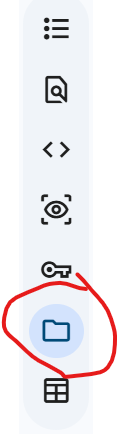

In [4]:
#Extract the folder
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content")

print("Dataset extracted.")

Dataset extracted.


In [5]:
#@title 3) Set paths (EDIT ME IF REQUIRED)
import os

# 🟨 STUDENT TODO: Set this to your Drive path
# Example: '/content/drive/MyDrive/data'
DATA_ROOT = "/content/"

TRAIN_DIR = os.path.join(DATA_ROOT, 'data', 'train')
SUBMISSION_DIR = os.path.join(DATA_ROOT, 'data', 'submission')

print('TRAIN_DIR:', TRAIN_DIR)
print('SUBMISSION_DIR:', SUBMISSION_DIR)
assert os.path.exists(TRAIN_DIR), 'Train directory not found'
assert os.path.exists(SUBMISSION_DIR), 'Submission directory not found'


TRAIN_DIR: /content/data/train
SUBMISSION_DIR: /content/data/submission


In [6]:
#@title 🔍 Dataset Safety Check (DO NOT MODIFY)

import os
import pandas as pd

print("Checking dataset structure...\n")

train_dir = os.path.join(DATA_ROOT, "data", "train")
submission_dir = os.path.join(DATA_ROOT, "data", "submission")

assert os.path.exists(train_dir), "❌ Missing data/train folder"
assert os.path.exists(submission_dir), "❌ Missing data/submission folder"

labels_path = os.path.join(train_dir, "labels.csv")
meta_path = os.path.join(submission_dir, "metadata.csv")

assert os.path.exists(labels_path), "❌ Missing labels.csv in train"
assert os.path.exists(meta_path), "❌ Missing metadata.csv in submission"

train_audio_dir = os.path.join(train_dir, "audio")
sub_audio_dir = os.path.join(submission_dir, "audio")

assert os.path.exists(train_audio_dir), "❌ Missing train/audio folder"
assert os.path.exists(sub_audio_dir), "❌ Missing submission/audio folder"

train_wavs = [f for f in os.listdir(train_audio_dir) if f.endswith(".wav")]
sub_wavs = [f for f in os.listdir(sub_audio_dir) if f.endswith(".wav")]

assert len(train_wavs) > 0, "❌ No training WAV files found"
assert len(sub_wavs) > 0, "❌ No submission WAV files found"

labels_df = pd.read_csv(labels_path)
meta_df = pd.read_csv(meta_path)

print(f"✅ Train samples: {len(labels_df)}")
print(f"✅ Submission samples: {len(meta_df)}")
print(f"✅ Train WAV files: {len(train_wavs)}")
print(f"✅ Submission WAV files: {len(sub_wavs)}")

# Check 3x robustness structure
base_ids = labels_df["clip_id"].astype(str)
expected_submission = len(base_ids) * 3

if len(meta_df) == expected_submission:
    print("✅ Submission contains clean/noisy/bandlimited versions (3x check passed)")
else:
    print("⚠️ Submission count does not match expected 3x structure")

print("\n🎉 Dataset structure looks correct.")


Checking dataset structure...

✅ Train samples: 1200
✅ Submission samples: 1200
✅ Train WAV files: 1200
✅ Submission WAV files: 1200
⚠️ Submission count does not match expected 3x structure

🎉 Dataset structure looks correct.


In [7]:
#@title 4) Imports
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score


## Load training labels

In [8]:
labels_csv = os.path.join(TRAIN_DIR, 'labels.csv')
audio_train_dir = os.path.join(TRAIN_DIR, 'audio')

df = pd.read_csv(labels_csv)
df['clip_id'] = df['clip_id'].astype(str)
df['label'] = df['label'].astype(str)
print('Train rows:', len(df))
df.head()


Train rows: 1200


,clip_id,label
0,1-100032-A-0,dog
1,1-100038-A-14,chirping_birds
2,1-100210-A-36,vacuum_cleaner
3,1-100210-B-36,vacuum_cleaner
4,1-101296-A-19,thunderstorm


In [ ]:
#@title ✅ Interactive Audio Player with Visualizations
import IPython.display as ipd
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import librosa.display

def play_audio_and_visualize(clip_id):
    row = df[df['clip_id'] == clip_id].iloc[0]
    path = os.path.join(audio_train_dir, f'{clip_id}.wav')
    y, sr = librosa.load(path, sr=16000)

    print(f"Clip ID: {clip_id} | Label: {row['label']}")

    # Display audio player BEFORE the plots
    display(ipd.Audio(y, rate=sr))

    # Visualization
    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

    # Time Domain: Waveform
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set(title='Time Domain (Waveform)', xlabel='Time (s)', ylabel='Amplitude')

    # Frequency Domain: Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax[1])
    ax[1].set(title='Frequency Domain (Spectrogram)')

    plt.tight_layout()
    plt.show()

clip_selector = widgets.Dropdown(
    options=df['clip_id'].head(100).tolist(),
    value=df['clip_id'].iloc[0],
    description='Train Clip:',
)

widgets.interact(play_audio_and_visualize, clip_id=clip_selector)

interactive(children=(Dropdown(description='Train Clip:', options=('1-100032-A-0', '1-100038-A-14', '1-100210-…

<function __main__.play_audio_and_visualize(clip_id)>

# 🧩 DSP Pipeline

Below are baseline functions.

Everything marked **STUDENT TODO** is where you should improve the pipeline.


In [9]:
!pip install noisereduce

In [10]:
#@title 5) Audio loading + preprocessing
import noisereduce as nr
from scipy.signal import butter, filtfilt
def load_audio(path, sr=16000):
    """Load mono audio, resample to sr."""
    y, sr_out = librosa.load(path, sr=sr, mono=True)
    y = np.nan_to_num(y).astype(np.float32)
    return y, sr_out

def get_mean_flatness(y):
    flatness = librosa.feature.spectral_flatness(y=y)
    return float(np.mean(flatness))

def estimate_frequency_range(y, sr, threshold_ratio=0.45):
    S = np.abs(librosa.stft(y))
    mean_spectrum = np.mean(S, axis=1)
    freqs = librosa.fft_frequencies(sr=sr)

    threshold = threshold_ratio * np.max(mean_spectrum)
    active_bins = np.where(mean_spectrum >= threshold)[0]

    if len(active_bins) == 0:
        return np.nan, np.nan, "No strong band detected"

    low_freq = freqs[active_bins[0]]
    high_freq = freqs[active_bins[-1]]
    freq_range_str = f"{low_freq:.0f} Hz - {high_freq:.0f} Hz"
    return low_freq, high_freq, freq_range_str

def lowpass_filter(y, sr, cutoff=1000, order=4):
    nyquist = 0.5 * sr
    normal_cutoff = min(cutoff / nyquist, 0.99)
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y_filtered = filtfilt(b, a, y)
    return y_filtered.astype(np.float32)

def preprocess_audio(y, sr):
    #Trim silence parts
    y,_ = librosa.effects.trim(y,top_db=33)

    # Noise Reduction & Low pass filter
    mean_flatness = get_mean_flatness(y)
    low_freq, high_freq, freq_range = estimate_frequency_range(y, sr, threshold_ratio=0.5)

    if not np.isnan(high_freq) and high_freq < 1000 and mean_flatness < 0.005:
        # print("Applying low-pass filter")
        y = lowpass_filter(y, sr, cutoff=1000, order=4)
    else:
        # print("Applying noise reduction")
        y = nr.reduce_noise(
            y=y,
            sr=sr,
            stationary=False,
            prop_decrease=0.8,
            time_constant_s=1.0,
            freq_mask_smooth_hz=300,
            time_mask_smooth_ms=50
        )

    # Remove DC offset
    y = y - np.mean(y)

    #RMS normalization
    rms = np.sqrt(np.mean(y ** 2)) + 1e-8
    target_rms = 0.3
    y = y * (target_rms / rms)

    return y.astype(np.float32)



In [ ]:
#@title (ADDTIONAL) Use to Visualise the Difference After Processed Vs Raw

def visualize_preprocessing(path, sr=16000):
    # Load raw audio
    y_raw, sr = load_audio(path, sr=sr)

    # Process audio using your actual preprocessing function
    y_processed = preprocess_audio(y_raw.copy(), sr)

    # Trimmed version for intermediate inspection
    y_trim, _ = librosa.effects.trim(y_raw, top_db=33)

    print("Original audio")
    display(ipd.Audio(y_raw, rate=sr))

    print("Processed audio")
    display(ipd.Audio(y_processed, rate=sr))

    fig, ax = plt.subplots(4, 1, figsize=(14, 12))

    # Original waveform
    librosa.display.waveshow(y_raw, sr=sr, ax=ax[0])
    ax[0].set_title(f"Time Domain (Waveform)({len(y_raw)/sr:.2f}s)")

    # Trimmed waveform
    librosa.display.waveshow(y_trim, sr=sr, ax=ax[1])
    ax[1].set_title(f"After silence trimming ({len(y_trim)/sr:.2f}s)")

    # Processed waveform
    librosa.display.waveshow(y_processed, sr=sr, ax=ax[2])
    ax[2].set_title(f"Final processed waveform ({len(y_processed)/sr:.2f}s)")

    # Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y_processed)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax[3])
    ax[3].set_title("Frequency Domain (Spectrogram)")
    fig.colorbar(img, ax=ax[3], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

Original audio


Processed audio


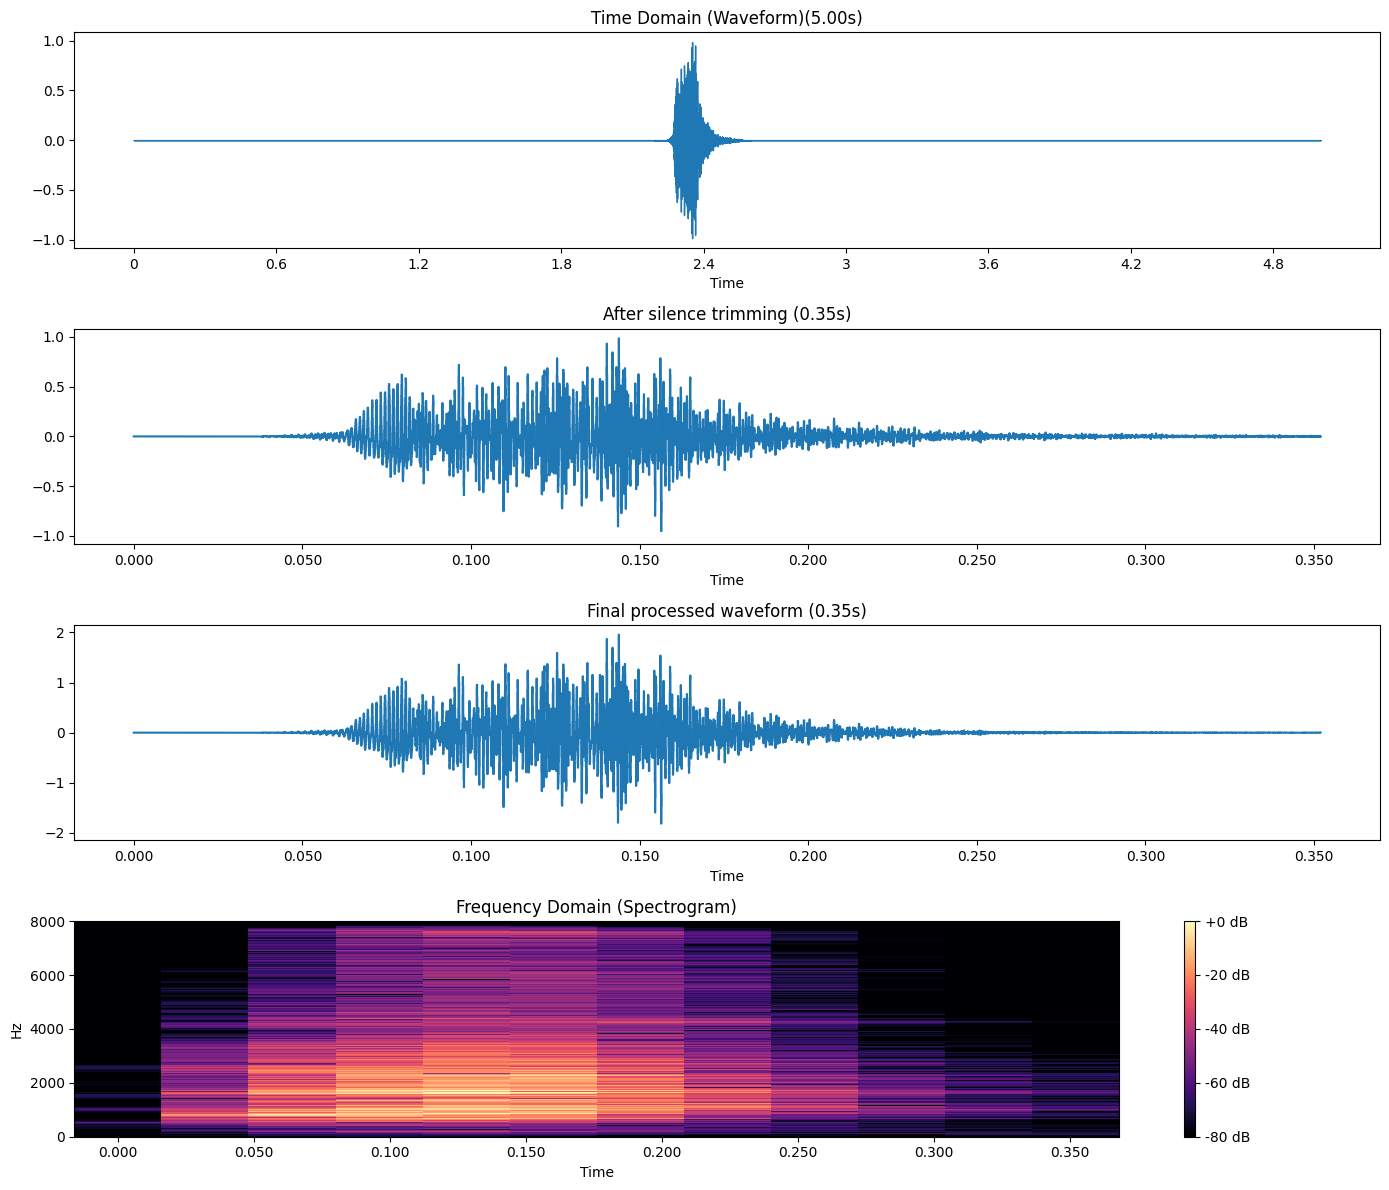

In [ ]:
path = os.path.join(audio_train_dir, f"{df['clip_id'].iloc[0]}.wav")
visualize_preprocessing(path)

In [ ]:
#@title (ADDTIONAL) Inspection Table For Frequency Emphasis and Flatness
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import ipywidgets as widgets
from IPython.display import display


def is_broadband_noise(y, sr, threshold=0.1):
    # Higher spectral flatness usually means more noise-like audio
    flatness = librosa.feature.spectral_flatness(y=y)
    mean_flatness = np.mean(flatness)
    return mean_flatness > threshold, mean_flatness

def estimate_frequency_range(y, sr, threshold_ratio=0.6):
    # Magnitude spectrogram
    S = np.abs(librosa.stft(y))

    # Average energy across time
    mean_spectrum = np.mean(S, axis=1)

    # Frequency bins
    freqs = librosa.fft_frequencies(sr=sr)

    # Keep frequencies above a percentage of the peak energy
    threshold = threshold_ratio * np.max(mean_spectrum)
    active_bins = np.where(mean_spectrum >= threshold)[0]

    if len(active_bins) == 0:
        return np.nan, np.nan, "No strong band detected"

    low_freq = freqs[active_bins[0]]
    high_freq = freqs[active_bins[-1]]
    freq_range_str = f"{low_freq:.0f} Hz - {high_freq:.0f} Hz"

    return low_freq, high_freq, freq_range_str



# Run through every clip in df

results = []

for _, row in df.iterrows():
    clip_id = row["clip_id"]
    path = os.path.join(audio_train_dir, f"{clip_id}.wav")

    if not os.path.exists(path):
        results.append({
            "clip_id": clip_id,
            "label": row.get("label", None),
            "mean_flatness": np.nan,
            "detected_broadband_noise": "FILE_NOT_FOUND"
        })
        continue

    try:
        y, sr = librosa.load(path, sr=16000)
        detected, mean_flatness = is_broadband_noise(y, sr, threshold=0.0001)
        low_freq, high_freq, freq_range = estimate_frequency_range(y, sr)

        results.append({
            "clip_id": clip_id,
            "label": row.get("label", None),
            "mean_flatness": mean_flatness,
            "detected_broadband_noise": detected,
            "low_freq_hz": low_freq,
            "high_freq_hz": high_freq,
            "estimated_freq_range": freq_range
        })

    except Exception as e:
        results.append({
            "clip_id": clip_id,
            "label": row.get("label", None),
            "mean_flatness": np.nan,
            "detected_broadband_noise": f"ERROR: {e}"
        })

results_df = pd.DataFrame(results)


# Print summary

print("Total clips checked:", len(results_df))
print("Detected as broadband noise:", (results_df["detected_broadband_noise"] == True).sum())
print("Not detected:", (results_df["detected_broadband_noise"] == False).sum())
print()

print("Clips detected by flatness:")
display(results_df[results_df["detected_broadband_noise"] == True]
        .sort_values(["label", "mean_flatness"], ascending=[True, False])
        .reset_index(drop=True))


Total clips checked: 1200
Detected as broadband noise: 1197
Not detected: 3

Clips detected by flatness:


,clip_id,label,mean_flatness,detected_broadband_noise,low_freq_hz,high_freq_hz,estimated_freq_range
0,1-24796-A-47,airplane,0.156256,True,54.6875,546.8750,55 Hz - 547 Hz
1,2-96654-A-47,airplane,0.062704,True,132.8125,359.3750,133 Hz - 359 Hz
2,1-11687-A-47,airplane,0.053787,True,46.8750,78.1250,47 Hz - 78 Hz
3,2-98866-A-47,airplane,0.047248,True,117.1875,125.0000,117 Hz - 125 Hz
4,3-143562-A-47,airplane,0.022652,True,109.3750,343.7500,109 Hz - 344 Hz
...,...,...,...,...,...,...,...
1192,2-109371-C-16,wind,0.000746,True,0.0000,281.2500,0 Hz - 281 Hz
1193,2-109371-D-16,wind,0.000704,True,0.0000,39.0625,0 Hz - 39 Hz
1194,1-47714-A-16,wind,0.000532,True,46.8750,85.9375,47 Hz - 86 Hz
1195,3-246513-A-16,wind,0.000398,True,7.8125,15.6250,8 Hz - 16 Hz


In [11]:
#@title 6) Feature extraction (baseline: MFCC stats)

def features_mfcc_stats(y, sr, n_mfcc=20, n_fft=1024, hop=256):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop)
    d1 = librosa.feature.delta(mfcc)
    d2 = librosa.feature.delta(mfcc, order=2)

    def stats(M):
        # return np.concatenate([M.mean(axis=1), M.std(axis=1)], axis=0)
        return np.concatenate([
            M.mean(axis=1),
            M.std(axis=1),
            np.median(M, axis=1)
        ], axis=0)

    return np.concatenate([stats(mfcc), stats(d1), stats(d2)], axis=0).astype(np.float32)

def extract_features(path, sr=16000):

    def stats(M):
        return np.concatenate([
            M.mean(axis=1),
            M.std(axis=1),
            np.median(M, axis=1)
        ], axis=0)

    y, sr = load_audio(path, sr=sr)
    y = preprocess_audio(y, sr)

    n_fft = 1028
    hop = 256

    # MFCC
    feat_mfcc = features_mfcc_stats(y, sr, n_mfcc=20, n_fft=n_fft, hop=hop)


    # Log Spectrogram
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))**2
    logS = librosa.power_to_db(S + 1e-10)
    feat_specgram = stats(logS)

    # Spectral / time-domain features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop)

    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=n_fft, hop_length=hop)

    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop)
    rms = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop)

    # feat_logmel = stats(mel)
    feat_spec = np.concatenate([
        stats(centroid),
        stats(bandwidth),
        stats(rolloff),
        stats(flatness),
        stats(contrast),
        stats(zcr),
        stats(rms)
    ], axis=0)

    feat = np.concatenate([feat_mfcc,feat_specgram, feat_spec], axis=0)
    return feat.astype(np.float32)


In [12]:
#@title 7) Build training feature matrix (may take a few minutes)

X, y = [], []
classes = sorted(df['label'].unique().tolist())
label_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_label = {i:c for c,i in label_to_idx.items()}

for _, r in tqdm(df.iterrows(), total=len(df)):
    clip_id = r['clip_id']
    wav_path = os.path.join(audio_train_dir, f'{clip_id}.wav')
    X.append(extract_features(wav_path))
    y.append(label_to_idx[r['label']])

X = np.stack(X, axis=0)
y = np.array(y, dtype=np.int64)
print('X shape:', X.shape, 'num_classes:', len(classes))


100%|██████████| 1200/1200 [05:26<00:00,  3.68it/s]

X shape: (1200, 1764) num_classes: 50


# 🧠 Model Training

Baseline = Logistic Regression.

🟨 **STUDENT TODO:** You can replace this with SVM, RandomForest, GradientBoosting, etc.


In [13]:
#@title 8) Train/Validation + Baseline model
import joblib
from google.colab import files
from sklearn.svm import SVC
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 🟨 STUDENT TODO:

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=0.5,
        max_iter=5000,
        class_weight='balanced'
    ))
])

model.fit(X_tr, y_tr)
y_pred = model.predict(X_va)

print(classification_report(y_va, y_pred, target_names=[idx_to_label[i] for i in range(len(classes))]))
print('Macro-F1:', f1_score(y_va, y_pred, average='macro'))

# Save the model locally
model_filename = GROUP_ID + '_model'+'.joblib'
joblib.dump(model, model_filename)
print(f'Model saved as {model_filename}. Downloading to your computer...')
files.download(model_filename)

                  precision    recall  f1-score   support

        airplane       0.67      0.40      0.50         5
       breathing       0.50      0.80      0.62         5
  brushing_teeth       0.75      0.60      0.67         5
     can_opening       1.00      0.80      0.89         5
        car_horn       0.00      0.00      0.00         5
             cat       0.80      0.80      0.80         5
        chainsaw       0.67      0.80      0.73         5
  chirping_birds       1.00      1.00      1.00         5
    church_bells       1.00      0.60      0.75         5
        clapping       0.67      0.80      0.73         5
     clock_alarm       0.67      0.40      0.50         5
      clock_tick       0.29      0.40      0.33         5
        coughing       0.50      0.40      0.44         5
             cow       0.67      0.50      0.57         4
  crackling_fire       0.80      0.80      0.80         5
        crickets       0.75      0.60      0.67         5
            c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@title (ADDITIONAL)  Model Comparison Against SVM / Random Forest/ Logistic Regression / KNN
import joblib
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score

# Split data
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf',
            C=0.5,
            gamma='scale',
            class_weight='balanced',
            max_iter=5000
        ))
    ]),

    "LogisticRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.5,
            class_weight='balanced',
            max_iter=5000,
            solver='lbfgs',
            multi_class='auto'
        ))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),


    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(
            n_neighbors=3,
            weights='distance',
            metric='minkowski',
            p=2
        ))
    ]),
}

results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_va)

    macro_f1 = f1_score(y_va, y_pred, average='macro')
    results[model_name] = {
        'model': model,
        'macro_f1': macro_f1
    }

    print(f"=== {model_name} Results ===")
    print(classification_report(
        y_va,
        y_pred,
        target_names=[idx_to_label[i] for i in range(len(classes))]
    ))
    print('Macro-F1:', macro_f1)

print(f"\n{'='*60}")
print("Summary of Macro-F1 Scores:")
for model_name, info in results.items():
    print(f"{model_name}: {info['macro_f1']:.4f}")

# Find best model
best_model_name = max(results, key=lambda k: results[k]['macro_f1'])
best_model = results[best_model_name]['model']

print(f"\nBest model: {best_model_name}")
print(f"Best Macro-F1: {results[best_model_name]['macro_f1']:.4f}")



Training SVM...
=== SVM Results ===
                  precision    recall  f1-score   support

        airplane       0.30      0.60      0.40         5
       breathing       0.60      0.60      0.60         5
  brushing_teeth       0.45      1.00      0.62         5
     can_opening       0.40      0.40      0.40         5
        car_horn       1.00      0.20      0.33         5
             cat       0.00      0.00      0.00         5
        chainsaw       0.25      0.40      0.31         5
  chirping_birds       0.75      0.60      0.67         5
    church_bells       0.00      0.00      0.00         5
        clapping       0.20      0.20      0.20         5
     clock_alarm       0.50      0.60      0.55         5
      clock_tick       0.14      0.20      0.17         5
        coughing       0.30      0.60      0.40         5
             cow       0.00      0.00      0.00         4
  crackling_fire       0.67      0.40      0.50         5
        crickets       1.00      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/l

=== LogisticRegression Results ===
                  precision    recall  f1-score   support

        airplane       0.67      0.40      0.50         5
       breathing       0.50      0.80      0.62         5
  brushing_teeth       0.75      0.60      0.67         5
     can_opening       1.00      0.80      0.89         5
        car_horn       0.00      0.00      0.00         5
             cat       0.80      0.80      0.80         5
        chainsaw       0.67      0.80      0.73         5
  chirping_birds       1.00      1.00      1.00         5
    church_bells       1.00      0.60      0.75         5
        clapping       0.67      0.80      0.73         5
     clock_alarm       0.67      0.40      0.50         5
      clock_tick       0.29      0.40      0.33         5
        coughing       0.50      0.40      0.44         5
             cow       0.67      0.50      0.57         4
  crackling_fire       0.80      0.80      0.80         5
        crickets       0.75      0.6

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 🧪 (Optional) Training-time augmentation

If you want to improve robustness, add augmentation in feature extraction.

🟨 **STUDENT TODO:** Implement noise/bandpass/gain augmentation during training.

Tip: you can augment the waveform `y` before computing features.


In [14]:
#@title 9) Load submission metadata

sub_meta = pd.read_csv(os.path.join(SUBMISSION_DIR, 'metadata.csv'))
sub_meta['clip_id'] = sub_meta['clip_id'].astype(str)
audio_sub_dir = os.path.join(SUBMISSION_DIR, 'audio')
print('Submission rows:', len(sub_meta))
sub_meta.head()


Submission rows: 1200


,clip_id
0,5-103415-A-2__clean
1,5-103416-A-2__clean
2,5-103418-A-2__clean
3,5-103420-A-2__clean
4,5-103421-A-2__clean


# ✅ Generate predictions.csv (THIS IS WHAT YOU SUBMIT)

This will run your feature extractor + model on every clip in `data/submission/audio`.

Make sure your output file name includes your team ID.


In [15]:
#@title 10) Predict on submission set and write CSV
from google.colab import files

OUT_CSV = f'{GROUP_ID}_predictions.csv' # 🟨 STUDENT TODO: Ensure You have entered the correct ID earlier

pred_rows = []
for _, r in tqdm(sub_meta.iterrows(), total=len(sub_meta)):
    clip_id = r['clip_id']
    wav_path = os.path.join(audio_sub_dir, f'{clip_id}.wav')
    feat = extract_features(wav_path)
    pred_idx = int(model.predict(feat.reshape(1, -1))[0])
    pred_label = idx_to_label[pred_idx]
    pred_rows.append((clip_id, pred_label))

out = pd.DataFrame(pred_rows, columns=['clip_id', 'predicted_label'])
out.to_csv(OUT_CSV, index=False)

print(f'Predictions saved to {OUT_CSV}. Downloading to your computer...')
files.download(OUT_CSV)

100%|██████████| 1200/1200 [05:13<00:00,  3.83it/s]

Predictions saved to Pr_02_predictions.csv. Downloading to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📤 How to submit
Upload to the model file (.joblib) and the predictions (.csv) to your xsite Dropbox.

**You only submit your model and prediction CSV and not the code.**
